# First Neural Network with Keras Tutorial

## Overview

In [1]:
import numpy as np
import tensorflow as tf  # deep learning library. Tensors are just multi-dimensional arrays
from tensorflow import (
    keras,
)  # TensorFlow's high-level API for building and training deep learning models

from keras import (
    models,
    layers,
    optimizers,
    losses,
    metrics,
)  # Keras is a high-level API for TensorFlow
from keras.datasets import mnist  # MNIST dataset (handwritten digits)
from keras.utils import to_categorical  # built-in function for one-hot encoding

import matplotlib.pyplot as plt  # plotting library

In [2]:
(train_data, train_labels), (test_data, test_labels) = (
    mnist.load_data()
)  # load MNIST dataset
# 60,000 images in the training set, and each image is 28 x 28 pixels
print("train_images.shape:", train_data.shape)  # (60000, 28, 28)

train_images.shape: (60000, 28, 28)


Label: 5


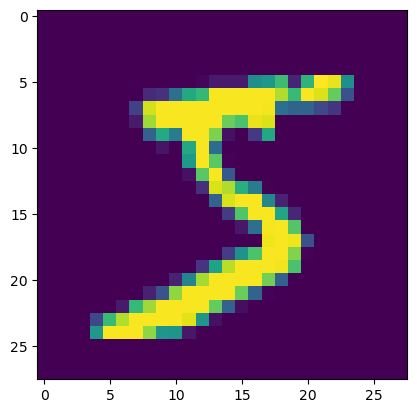

In [3]:
test_img: int = 0
plt.imshow(train_data[test_img])  # show the first image in the training set
print(f"Label: {train_labels[test_img]}")  # 5
# print as matrix with good formatting
# print("train_images[0]:\n", np.array2string(train_images[0], precision=1, separator=',', suppress_small=True))

Create the Neural Network Model

The model is defined in Keras as a sequence of layers. We create a Sequential
model and add layers one at a time until we are happy with our network topology.
The first thing to get right is to ensure the input layer has the right number
of inputs. This can be specified when creating the first layer with the input
dim argument and setting it to 8 for the 8 input variables.

In [4]:
model: models.Sequential = models.Sequential()  # create a sequential model

# add layers to the model
model.add(
    layers.Dense(  # input layer
        512,  # number of neurons in the layer
        activation="relu",  # rectified linear unit (ReLU)
        input_shape=(28 * 28,),
    )
)  # input shape (28 x 28 = 784)

model.add(
    layers.Dense(  # output layer
        10,  # number of neurons in the layer
        activation="softmax",
    )
)  # softmax activation = output values are probabilities

<!-- MAKE A REPRESENTATION OF THE NEURAL NETWORK ABOVE USING MERMAID -->

```mermaid
graph LR
    subgraph Input Layer
        A((x1))
        B((x2))
        C((...))
        D((28*28)) 
    end

    subgraph Output Layer
        A --> E((h1))
        A --> F((h2))
        B --> E((h1))
        B --> F((h2))
        C --> E((h1))
        C --> F((h2))
        D --> E((h1))
        D --> F((h2))
        
    end
```

In [5]:
model.compile(
    optimizer="rmsprop",  # optimizer
    loss="categorical_crossentropy",  # loss function
    metrics=["accuracy"],
)  # metric to monitor

Compile Neural Network Model

We must specify the loss function to use to evaluate a set of weights, the
optimizer used to search through different weights for the network and any
optional metrics we would like to collect and report during training. In this
case we will use logarithmic loss, which for a binary classification problem is
defined in Keras as “binary_crossentropy“. We will also use the efficient
gradient descent algorithm “adam” for no other reason that it is an efficient
default. Learn more about the Adam optimization algorithm in the paper “Adam: A
Method for Stochastic Optimization“.

In [6]:
model.summary()  # print a summary of the model

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dense_1 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407,050
Trainable params: 407,050
Non-trainable params: 0
_________________________________________________________________


Reshape Data


train_images.shape: (60000, 784)
test_images.shape: (10000, 784)


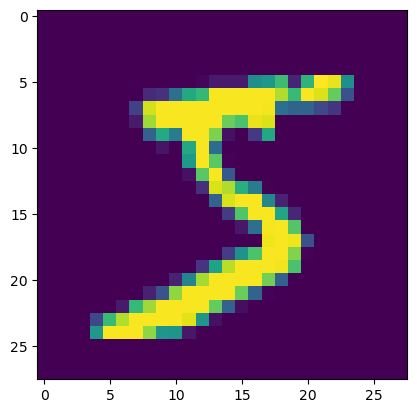

In [7]:
# Reshape the training and test images to 28 x 28 x 1
x_train = train_data.reshape((60000, 28 * 28))  # reshape training images
x_train = x_train.astype("float32") / 255  # normalize training images
print("train_images.shape:", x_train.shape)  # (60000, 784)
plt.imshow(
    x_train[test_img].reshape(28, 28)
)  # show the first image in the training set

x_test = test_data.reshape((10000, 28 * 28))  # reshape test images
x_test = x_test.astype("float32") / 255  # normalize test images
print("test_images.shape:", x_test.shape)  # (10000, 784)

In [8]:
# One-hot encode the training and test labels
y_train = to_categorical(train_labels)  # one-hot encode training labels
print("train_labels.shape:", y_train.shape)  # (60000, 10)
print(
    "train_labels[0]:", y_train[0]
)  # vector of 10 elements, all values are 0 except for the real value

y_test = to_categorical(test_labels)  # one-hot encode test labels
print("test_labels.shape:", y_test.shape)  # (10000, 10)

train_labels.shape: (60000, 10)
train_labels[0]: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
test_labels.shape: (10000, 10)


## Train the Neural Network Model

We can train or fit our model on our loaded data by calling the fit() function
on the model.

In [9]:
model.fit(  # train the model
    x_train,  # training data
    y_train,  # training labels
    epochs=5,  # number of epochs (iterations on the dataset)
    batch_size=128,  # number of samples per gradient update
)

Epoch 1/5


469/469 [==============================] - 2s 3ms/step - loss: 0.2674 - accuracy: 0.9234
Epoch 2/5
469/469 [==============================] - 1s 3ms/step - loss: 0.1088 - accuracy: 0.9679
Epoch 3/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0712 - accuracy: 0.9789
Epoch 4/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0506 - accuracy: 0.9847
Epoch 5/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0380 - accuracy: 0.9886


Then, to evaluate the performance of the neural network on the training data, we
can call the evaluate() function on the model and pass in the training data and
the expected training output.

In [10]:
model.evaluate(x_test, y_test)  # evaluate the model on the test set

313/313 [==============================] - 0s 768us/step - loss: 0.0581 - accuracy: 0.9807


[0.058070726692676544, 0.9807000160217285]

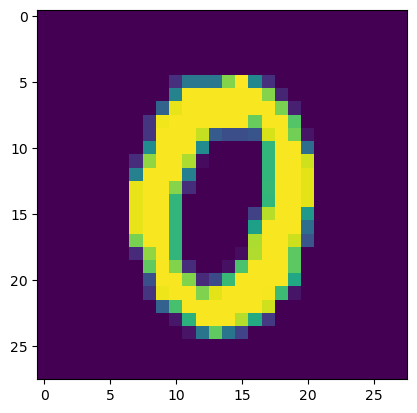

Label: 0
1/1 [==============================] - 0s 51ms/step
Prediction: 0


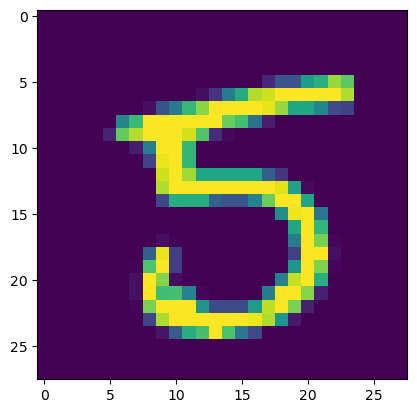

Label: 5
1/1 [==============================] - 0s 12ms/step
Prediction: 5


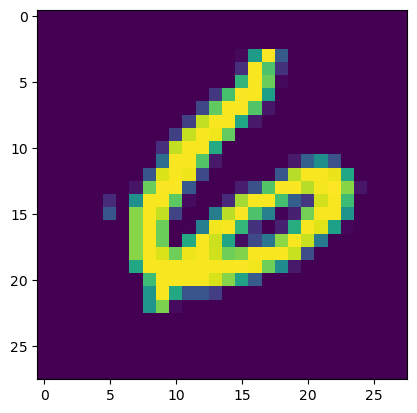

Label: 6
1/1 [==============================] - 0s 11ms/step
Prediction: 6


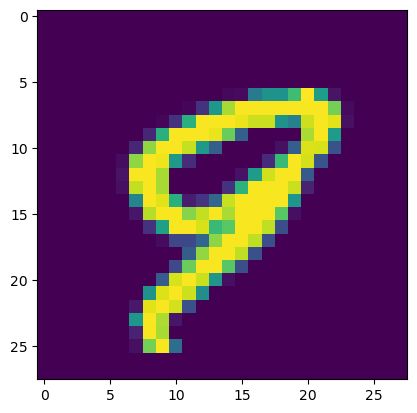

Label: 9
1/1 [==============================] - 0s 12ms/step
Prediction: 9


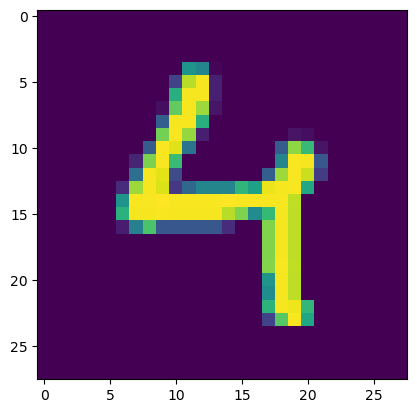

Label: 4
1/1 [==============================] - 0s 13ms/step
Prediction: 4


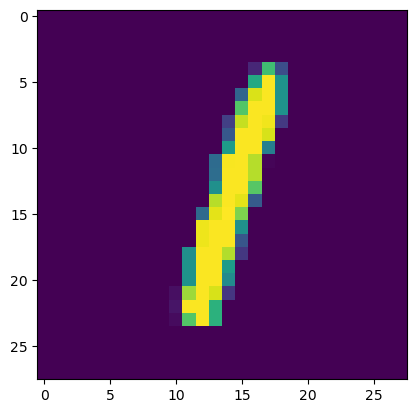

Label: 1
1/1 [==============================] - 0s 13ms/step
Prediction: 1


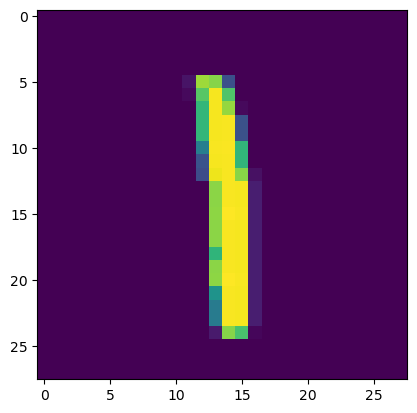

Label: 1
1/1 [==============================] - 0s 12ms/step
Prediction: 1


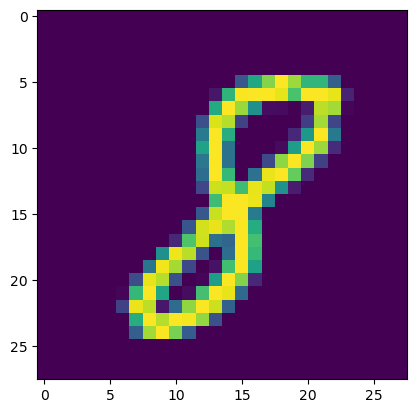

Label: 8
1/1 [==============================] - 0s 14ms/step
Prediction: 8


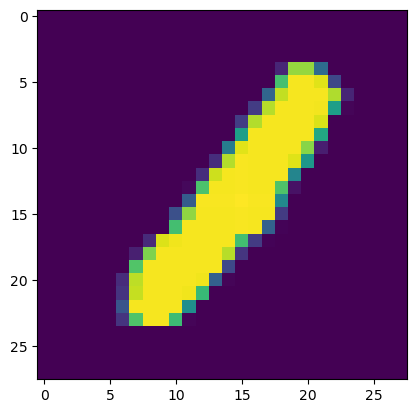

Label: 1
1/1 [==============================] - 0s 16ms/step
Prediction: 1


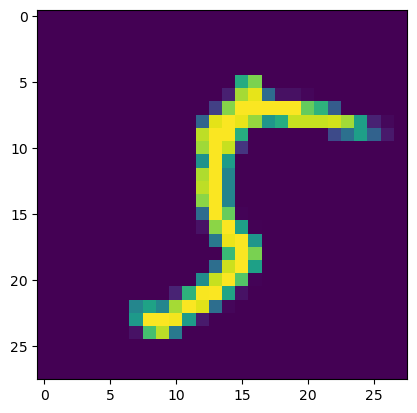

Label: 5
1/1 [==============================] - 0s 12ms/step
Prediction: 5


In [11]:
# TEST THE ACURACY OF THE MODEL (print results)
for i in range(10):  # test 10 random images
    test_img: int = np.random.randint(0, test_data.shape[0])
    plt.imshow(
        test_data[test_img].reshape(28, 28)
    )  # show the first image in the training set
    plt.show()
    print(f"Label: {test_labels[test_img]}")  # print the real label
    print(
        f"Prediction: {np.argmax(model.predict(test_data[test_img].reshape(1, 28 * 28)))}"
    )  # print the predicted label

In [12]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))

if tf.test.is_gpu_available():
    print("GPU is being used")
else:
    print("GPU is NOT being used")

Num GPUs Available:  0
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU is NOT being used
